In [1]:
from pathlib import Path
import random
import shutil
import yaml
import cv2
import numpy as np
from tqdm import tqdm

# Notebook sits in:
# project_root / "Training Scripts" / train_yolo_seg.ipynb

training_scripts_dir = Path.cwd()
project_root = training_scripts_dir.parent

# Existing YOLO-seg dataset made from Cellpose annotations
source_yolo_dir = project_root / "yolo_files" / "yolo_seg"

# New tiled YOLO-seg dataset
tiled_yolo_dir = project_root / "yolo_files" / "yolo_seg_tiled"

source_images_train_dir = source_yolo_dir / "images" / "train"
source_labels_train_dir = source_yolo_dir / "labels" / "train"

tiled_images_train_dir = tiled_yolo_dir / "images" / "train"
tiled_labels_train_dir = tiled_yolo_dir / "labels" / "train"

for d in [
  tiled_images_train_dir,
  tiled_labels_train_dir
]:
  d.mkdir(parents=True, exist_ok=True)

# Tiling settings
tile_size = 768
overlap = 128
stride = tile_size - overlap

# Annotation filtering
min_mask_area_px = 8
min_contour_points = 3
polygon_simplification_factor = 0.005

# Dataset settings
class_id = 0
class_name = "bubble"

# Behavior
overwrite_existing_tiles = True
skip_empty_tiles = True

print("Project root:", project_root)
print("Source YOLO folder:", source_yolo_dir)
print("Tiled YOLO folder:", tiled_yolo_dir)

Project root: d:\2026\aspire
Source YOLO folder: d:\2026\aspire\yolo_files\yolo_seg
Tiled YOLO folder: d:\2026\aspire\yolo_files\yolo_seg_tiled


In [2]:
def read_yolo_seg_label(label_path):
  """
  Reads YOLO-seg annotation file.

  Each line:
    class_id x1 y1 x2 y2 x3 y3 ...

  Coordinates are normalized.
  """
  objects = []

  if not label_path.exists():
    return objects

  with open(label_path, "r") as f:
    lines = f.read().strip().splitlines()

  for line in lines:
    parts = line.strip().split()

    if len(parts) < 7:
      continue

    cls = int(float(parts[0]))
    coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)

    if len(coords) % 2 != 0:
      continue

    points = coords.reshape(-1, 2)
    objects.append((cls, points))

  return objects


def yolo_objects_to_instance_mask(objects, image_width, image_height):
  """
  Converts YOLO-seg polygons into an integer instance mask.

  0 = background
  1, 2, 3, ... = object IDs
  """
  instance_mask = np.zeros((image_height, image_width), dtype=np.int32)

  object_id = 1

  for cls, points_norm in objects:
    points_px = points_norm.copy()
    points_px[:, 0] *= image_width
    points_px[:, 1] *= image_height
    points_px = np.round(points_px).astype(np.int32)

    if points_px.shape[0] < min_contour_points:
      continue

    cv2.fillPoly(instance_mask, [points_px], object_id)
    object_id += 1

  return instance_mask


def mask_tile_to_yolo_segments(mask_tile, tile_width, tile_height):
  """
  Converts a cropped integer instance mask into YOLO-seg polygons.
  """
  yolo_lines = []

  object_ids = np.unique(mask_tile)
  object_ids = object_ids[object_ids != 0]

  for object_id in object_ids:
    binary_mask = (mask_tile == object_id).astype(np.uint8)

    area = int(binary_mask.sum())
    if area < min_mask_area_px:
      continue

    contours, _ = cv2.findContours(
      binary_mask,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
      continue

    contour = max(contours, key=cv2.contourArea)

    if len(contour) < min_contour_points:
      continue

    arc_length = cv2.arcLength(contour, True)
    epsilon = polygon_simplification_factor * arc_length
    contour = cv2.approxPolyDP(contour, epsilon, True)

    contour = contour.squeeze()

    if contour.ndim != 2:
      continue

    if contour.shape[0] < min_contour_points:
      continue

    normalized_points = []

    for x, y in contour:
      x_norm = float(x) / tile_width
      y_norm = float(y) / tile_height

      x_norm = min(max(x_norm, 0.0), 1.0)
      y_norm = min(max(y_norm, 0.0), 1.0)

      normalized_points.extend([x_norm, y_norm])

    if len(normalized_points) >= 6:
      line = str(class_id) + " " + " ".join(f"{p:.6f}" for p in normalized_points)
      yolo_lines.append(line)

  return yolo_lines


def get_tile_origins(image_width, image_height, tile_size, stride):
  """
  Returns top-left tile origins.
  Includes edge tiles so the full image is covered.
  """
  x_origins = list(range(0, max(image_width - tile_size + 1, 1), stride))
  y_origins = list(range(0, max(image_height - tile_size + 1, 1), stride))

  if len(x_origins) == 0 or x_origins[-1] != image_width - tile_size:
    x_origins.append(max(image_width - tile_size, 0))

  if len(y_origins) == 0 or y_origins[-1] != image_height - tile_size:
    y_origins.append(max(image_height - tile_size, 0))

  return x_origins, y_origins

In [3]:
image_paths = sorted(
  list(source_images_train_dir.rglob("*.png")) +
  list(source_images_train_dir.rglob("*.jpg")) +
  list(source_images_train_dir.rglob("*.jpeg"))
)

paired_data = []

for image_path in image_paths:
  relative_path = image_path.relative_to(source_images_train_dir)
  label_path = source_labels_train_dir / relative_path.with_suffix(".txt")

  if label_path.exists():
    paired_data.append((image_path, label_path))

print(f"Found {len(image_paths)} source training images")
print(f"Found {len(paired_data)} images with YOLO-seg labels")

for image_path, label_path in paired_data[:5]:
  print("Image:", image_path.relative_to(source_images_train_dir))
  print("Label:", label_path.relative_to(source_labels_train_dir))
  print()

Found 1 source training images
Found 1 images with YOLO-seg labels
Image: 1.2mpm-6LPM-4fps-200us-dB20\1.2mpm-6LPM-200us-20dB-04242026141859-0.png
Label: 1.2mpm-6LPM-4fps-200us-dB20\1.2mpm-6LPM-200us-20dB-04242026141859-0.txt



In [4]:
def count_tiles_for_image(image_path, label_path):
  image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

  if image is None:
    print(f"Could not read image: {image_path}")
    return 0

  image_height, image_width = image.shape[:2]

  objects = read_yolo_seg_label(label_path)

  if len(objects) == 0:
    return 0

  x_origins, y_origins = get_tile_origins(
    image_width,
    image_height,
    tile_size,
    stride
  )

  return len(x_origins) * len(y_origins)


def tile_one_image(image_path, label_path, pbar=None):
  relative_path = image_path.relative_to(source_images_train_dir)
  relative_stem = relative_path.with_suffix("")

  image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

  if image is None:
    print(f"Could not read image: {image_path}")
    return 0, 0

  image_height, image_width = image.shape[:2]

  objects = read_yolo_seg_label(label_path)

  if len(objects) == 0:
    return 0, 0

  instance_mask = yolo_objects_to_instance_mask(
    objects,
    image_width,
    image_height
  )

  x_origins, y_origins = get_tile_origins(
    image_width,
    image_height,
    tile_size,
    stride
  )

  tiles_written = 0
  empty_tiles_skipped = 0

  for y0 in y_origins:
    for x0 in x_origins:
      x1 = min(x0 + tile_size, image_width)
      y1 = min(y0 + tile_size, image_height)

      image_tile = image[y0:y1, x0:x1]
      mask_tile = instance_mask[y0:y1, x0:x1]

      tile_height, tile_width = image_tile.shape[:2]

      yolo_lines = mask_tile_to_yolo_segments(
        mask_tile,
        tile_width,
        tile_height
      )

      if skip_empty_tiles and len(yolo_lines) == 0:
        empty_tiles_skipped += 1

        if pbar is not None:
          pbar.update(1)

        continue

      tile_name = f"{relative_stem.as_posix().replace('/', '__')}_x{x0:05d}_y{y0:05d}.png"

      output_image_path = tiled_images_train_dir / tile_name
      output_label_path = tiled_labels_train_dir / Path(tile_name).with_suffix(".txt")

      if output_image_path.exists() and output_label_path.exists() and not overwrite_existing_tiles:
        if pbar is not None:
          pbar.update(1)

        continue

      cv2.imwrite(str(output_image_path), image_tile)

      with open(output_label_path, "w") as f:
        f.write("\n".join(yolo_lines))

      tiles_written += 1

      if pbar is not None:
        pbar.update(1)

  return tiles_written, empty_tiles_skipped


total_tiles_required = 0

for image_path, label_path in paired_data:
  total_tiles_required += count_tiles_for_image(image_path, label_path)

print("Total tiles required:", total_tiles_required)

total_tiles_written = 0
total_empty_tiles_skipped = 0

with tqdm(total=total_tiles_required, desc="Tiling tiles", unit="tile") as pbar:
  for image_path, label_path in paired_data:
    tiles_written, empty_tiles_skipped = tile_one_image(
      image_path,
      label_path,
      pbar=pbar
    )

    total_tiles_written += tiles_written
    total_empty_tiles_skipped += empty_tiles_skipped

print("Done tiling.")
print("Tiles required:", total_tiles_required)
print("Tiles written:", total_tiles_written)
print("Empty tiles skipped:", total_empty_tiles_skipped)

Total tiles required: 63


Tiling tiles: 100%|██████████| 63/63 [00:36<00:00,  1.73tile/s]

Done tiling.
Tiles required: 63
Tiles written: 61
Empty tiles skipped: 2


In [5]:
# Since you currently do not have true validation images,
# this temporary YAML uses the training tiles as validation too.
#
# This is okay for testing whether the pipeline runs.
# It is NOT a meaningful validation score.

yaml_text = f"""path: {tiled_yolo_dir.as_posix()}
train: images/train
val: images/train

names:
  0: {class_name}
"""

yaml_path = tiled_yolo_dir / "data.yaml"

with open(yaml_path, "w") as f:
  f.write(yaml_text)

print(f"Wrote: {yaml_path}")
print()
print(yaml_text)

Wrote: d:\2026\aspire\yolo_files\yolo_seg_tiled\data.yaml

path: d:/2026/aspire/yolo_files/yolo_seg_tiled
train: images/train
val: images/train

names:
  0: bubble



In [6]:
from ultralytics import YOLO

# Start from a small segmentation model.
# Good options:
#   yolo11n-seg.pt = fastest, lowest VRAM
#   yolo11s-seg.pt = better, more VRAM
#
# For RTX 2070 8GB, start with nano.

model = YOLO("yolo11n-seg.pt")

results = model.train(
  data=str(yaml_path),
  task="segment",
  epochs=50,
  imgsz=768,
  batch=2,
  workers=1,
  device=0,
  project=str(project_root / "yolo_files" / "runs_yolo_seg"),
  name="bubble_yolo11n_seg_tiled",
  pretrained=True,
  patience=15,
  save=True,
  plots=True
)

New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.52  Python-3.11.15 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\2026\aspire\yolo_files\yolo_seg_tiled\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mo

In [7]:
# Find trained model

run_dir = project_root / "yolo_files" / "runs_yolo_seg" / "bubble_yolo11n_seg_tiled"
best_model_path = run_dir / "weights" / "best.pt"
last_model_path = run_dir / "weights" / "last.pt"

if best_model_path.exists():
  trained_model_path = best_model_path
else:
  trained_model_path = last_model_path

print("Using model:", trained_model_path)

Using model: d:\2026\aspire\yolo_files\runs_yolo_seg\bubble_yolo11n_seg_tiled\weights\best.pt


Visualizing: d:\2026\aspire\yolo_files\yolo_seg_tiled\images\train\1.2mpm-6LPM-4fps-200us-dB20__1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y00000.png

image 1/1 d:\2026\aspire\yolo_files\yolo_seg_tiled\images\train\1.2mpm-6LPM-4fps-200us-dB20__1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y00000.png: 768x768 223 bubbles, 53.4ms
Speed: 6.4ms preprocess, 53.4ms inference, 213.2ms postprocess per image at shape (1, 3, 768, 768)
Results saved to D:\2026\aspire\yolo_files\runs_yolo_seg_visualizations\single_tile_overlay


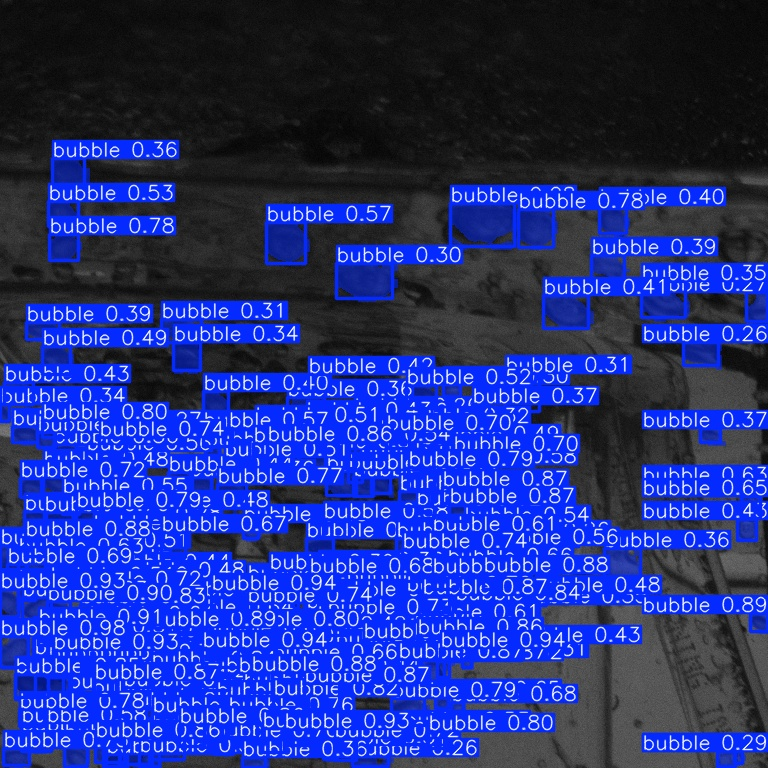

In [8]:
# Quick visualization on one tiled training image

from ultralytics import YOLO
from IPython.display import Image as DisplayImage, display

trained_model = YOLO(str(trained_model_path))

tile_images = sorted(
  list(tiled_images_train_dir.rglob("*.png")) +
  list(tiled_images_train_dir.rglob("*.jpg")) +
  list(tiled_images_train_dir.rglob("*.jpeg"))
)

test_tile_path = tile_images[0]

print("Visualizing:", test_tile_path)

pred_results = trained_model.predict(
  source=str(test_tile_path),
  imgsz=768,
  conf=0.25,
  device=0,
  save=True,
  project=str(project_root / "yolo_files" / "runs_yolo_seg_visualizations"),
  name="single_tile_overlay",
  exist_ok=True
)

saved_vis_dir = project_root / "yolo_files" / "runs_yolo_seg_visualizations" / "single_tile_overlay"
saved_images = sorted(
  list(saved_vis_dir.rglob("*.png")) +
  list(saved_vis_dir.rglob("*.jpg")) +
  list(saved_vis_dir.rglob("*.jpeg"))
)

display(DisplayImage(filename=str(saved_images[0])))

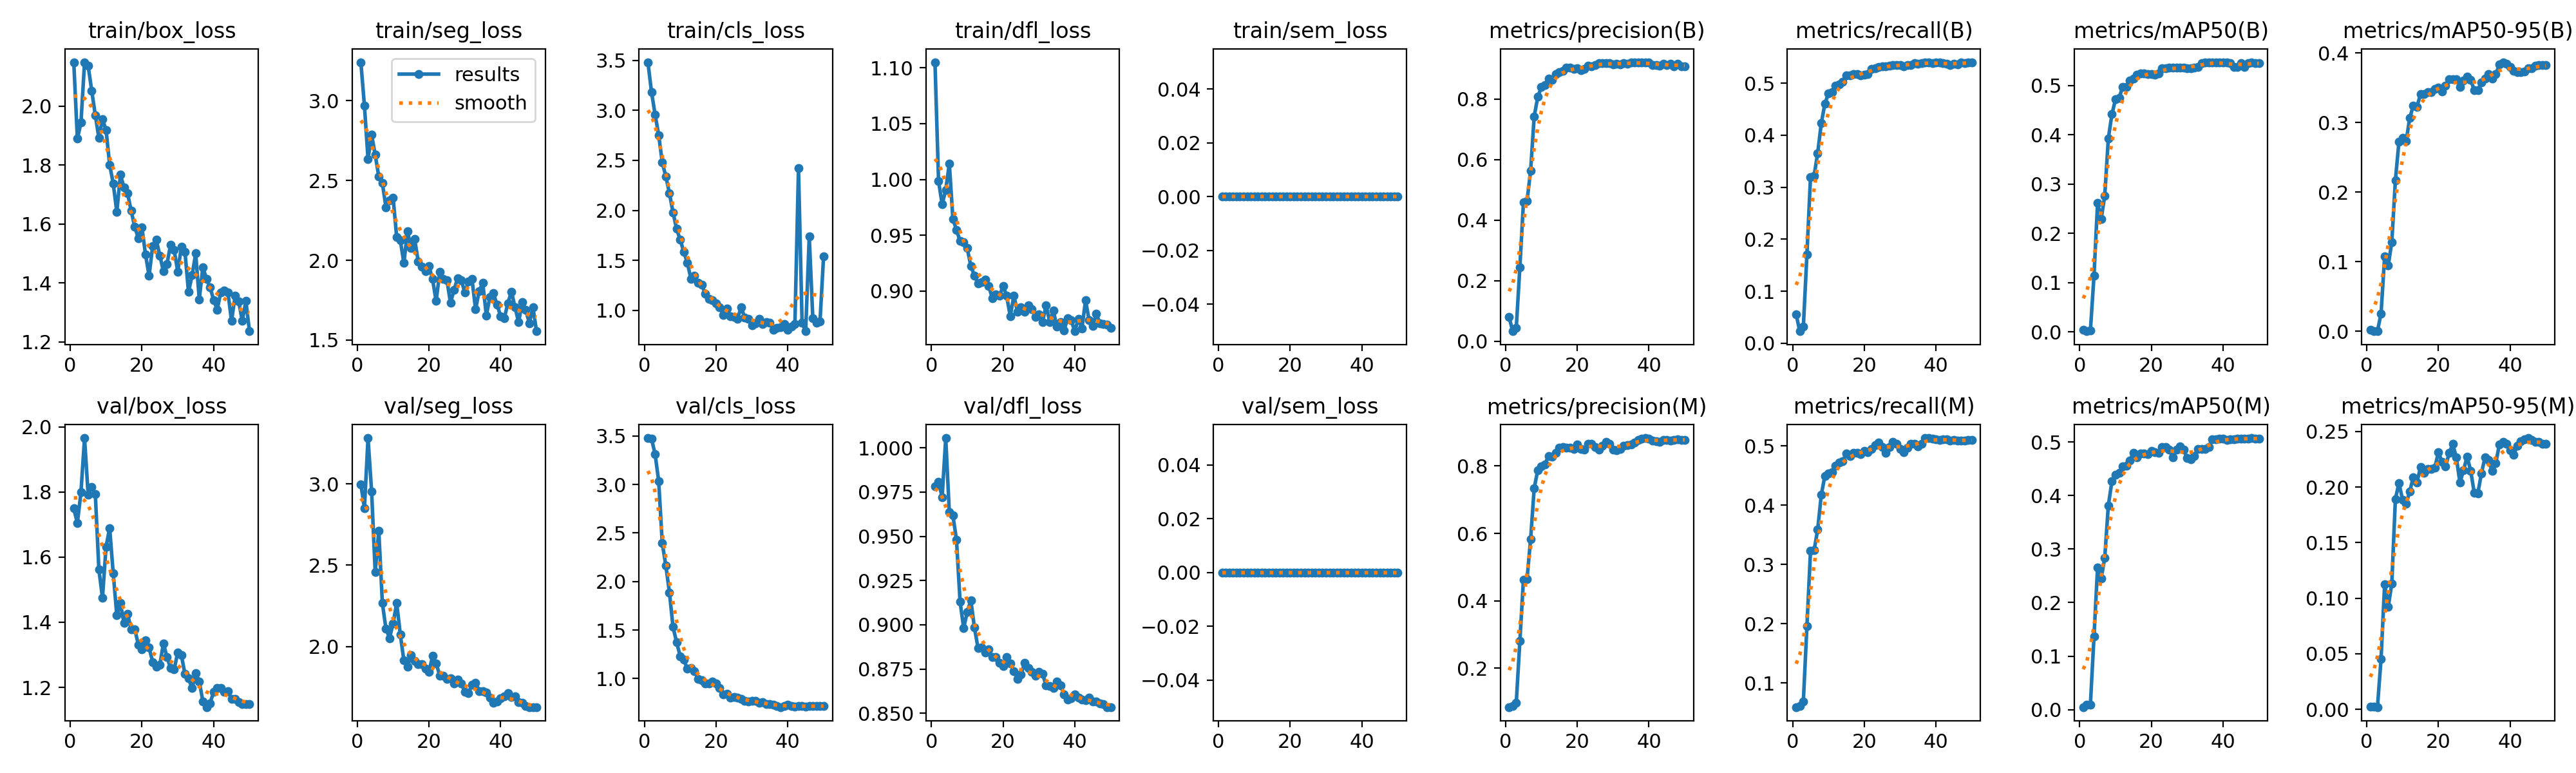

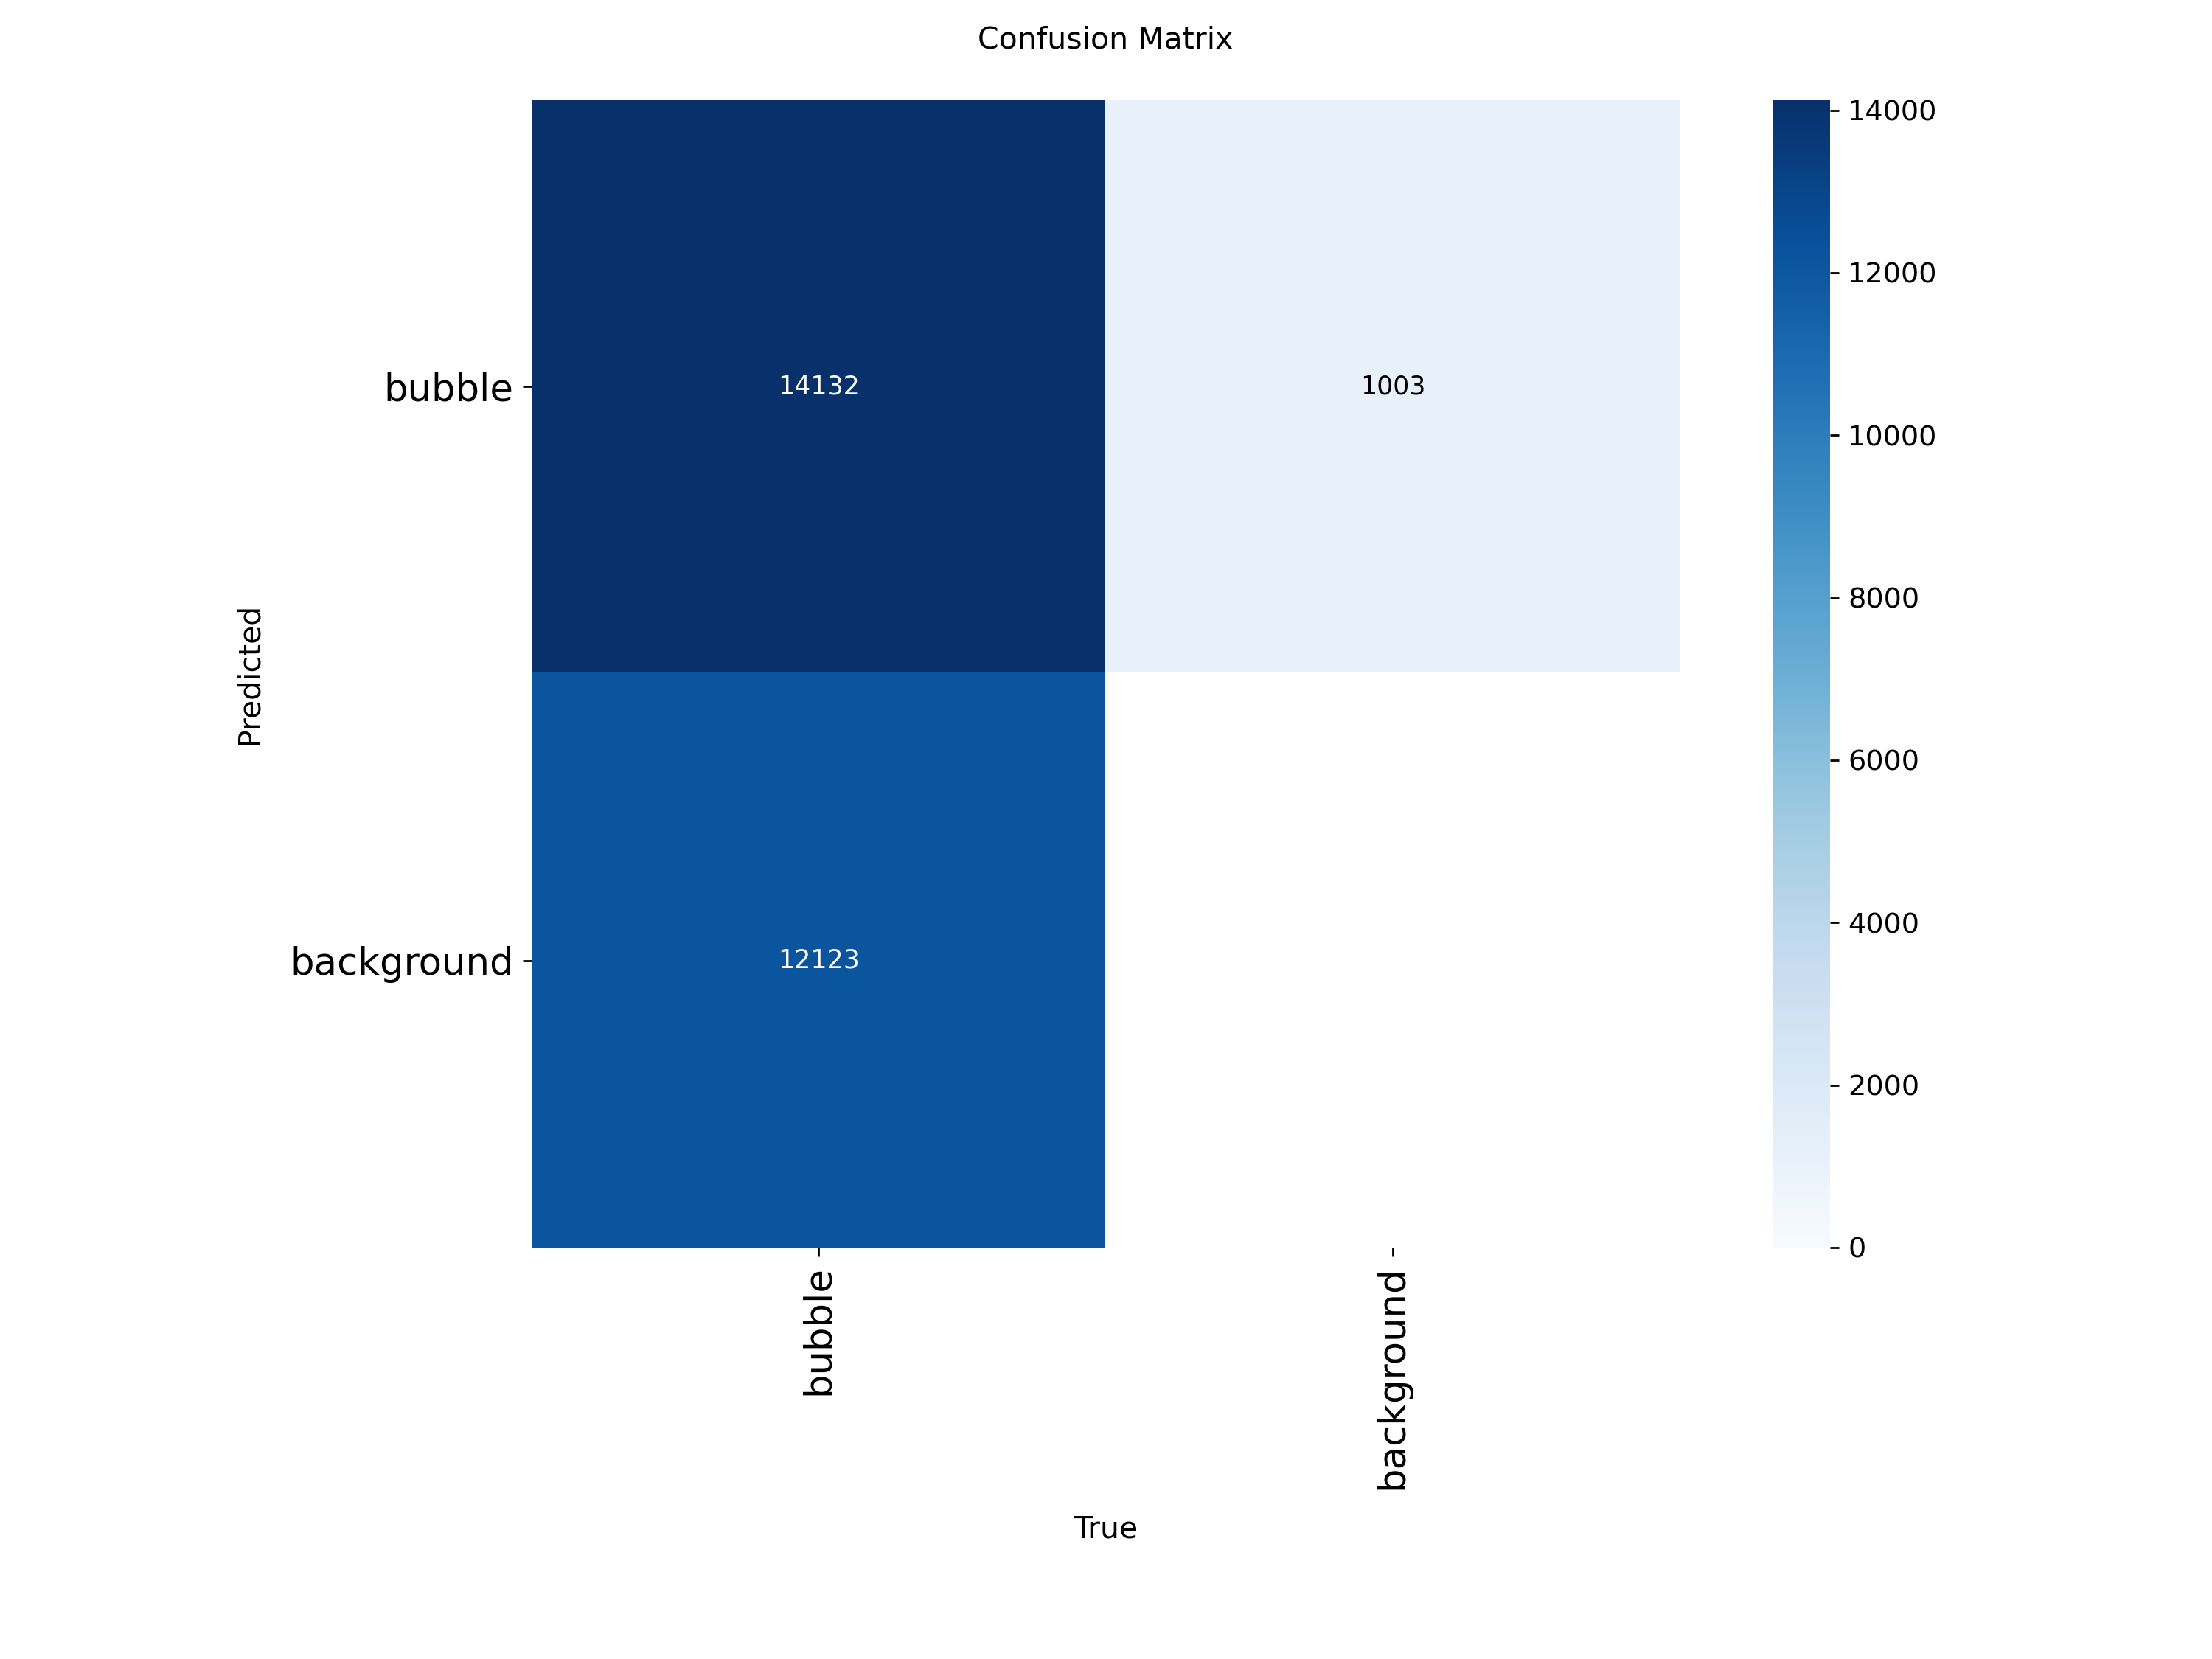

In [9]:
# Optional: visualize training curves/results after training

from IPython.display import Image as DisplayImage, display

results_png = run_dir / "results.png"
confusion_png = run_dir / "confusion_matrix.png"

if results_png.exists():
  display(DisplayImage(filename=str(results_png)))

if confusion_png.exists():
  display(DisplayImage(filename=str(confusion_png)))

In [10]:
# Optional separate script:
# Run tiled inference on ONE original full-size training image,
# then save YOLO's tile overlays.
#
# This does not merge masks back into one full image yet.
# It is mainly for visually checking whether the model learned bubbles.

full_image_path = paired_data[0][0]

full_image = cv2.imread(str(full_image_path), cv2.IMREAD_UNCHANGED)
full_h, full_w = full_image.shape[:2]

x_origins, y_origins = get_tile_origins(
  full_w,
  full_h,
  tile_size,
  stride
)

temp_inference_tiles_dir = project_root / "yolo_files" / "temp_inference_tiles"
temp_inference_tiles_dir.mkdir(exist_ok=True)

for old_file in temp_inference_tiles_dir.glob("*"):
  old_file.unlink()

for y0 in y_origins:
  for x0 in x_origins:
    x1 = min(x0 + tile_size, full_w)
    y1 = min(y0 + tile_size, full_h)

    tile = full_image[y0:y1, x0:x1]

    tile_path = temp_inference_tiles_dir / f"{full_image_path.stem}_x{x0:05d}_y{y0:05d}.png"
    cv2.imwrite(str(tile_path), tile)

pred_results = trained_model.predict(
  source=str(temp_inference_tiles_dir),
  imgsz=768,
  conf=0.25,
  device=0,
  save=True,
  project=str(project_root / "yolo_files" / "runs_yolo_seg_visualizations"),
  name="full_image_tiled_overlay",
  exist_ok=True
)

print("Saved tiled full-image overlays to:")
print(project_root / "yolo_files" / "runs_yolo_seg_visualizations" / "full_image_tiled_overlay")


image 1/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y00000.png: 768x768 223 bubbles, 25.9ms
image 2/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y00640.png: 768x768 300 bubbles, 14.4ms
image 3/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y01280.png: 768x768 222 bubbles, 14.3ms
image 4/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y01920.png: 768x768 51 bubbles, 14.2ms
image 5/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y02560.png: 768x768 27 bubbles, 14.3ms
image 6/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y03200.png: 768x768 19 bubbles, 14.3ms
image 7/63 d:\2026\aspire\yolo_files\temp_inference_tiles\1.2mpm-6LPM-200us-20dB-04242026141859-0_x00000_y03832.png: 768x768 2 bubbl